In [ ]:
# By Easwari M

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print("Shape of Dataset:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of Dataset: (545, 13)
Rows: 545
Columns: 13


In [4]:
target = "price"

features = df.drop("price", axis=1)

print("Target Column:", target)
print("Feature Columns:")
print(features.columns)

Target Column: price
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [5]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.dropna()

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())


      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2             1   
1  12250000  8960         4          4        4        3             1   
2  12250000  9960         3          2        2        2             1   
3  12215000  7500         4          2        2        3             1   
4  11410000  7420         4          1        2        2             1   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0              0             0                    0                    1   
1              0             0                    0                    1   
2              0             1                    0                    0   
3              0             1                    0                    1   
4              1             1                    0                    1   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0             1  

In [12]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [15]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression Results
MAE : 970043.403920164
RMSE: 1324506.9600914388
R2  : 0.6529242642153184


In [17]:
#Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2  : 0.611918531405699


In [19]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[mae_lr, mae_rf],
    'RMSE':[rmse_lr, rmse_rf],
    'R2 Score':[r2_lr, r2_rf]
})

print(comparison)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


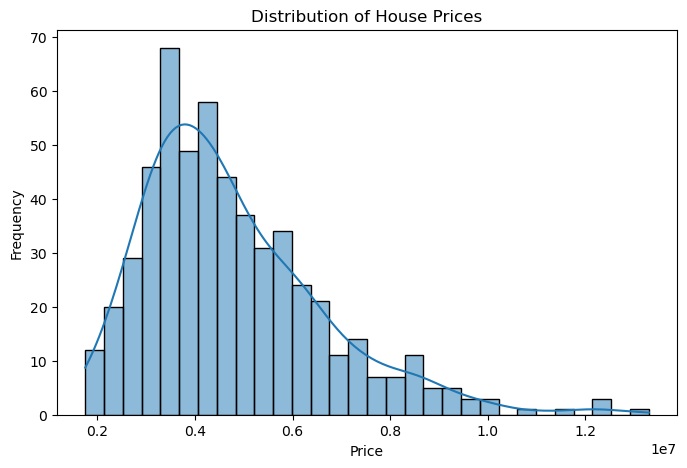

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'],
             bins=30,
             kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

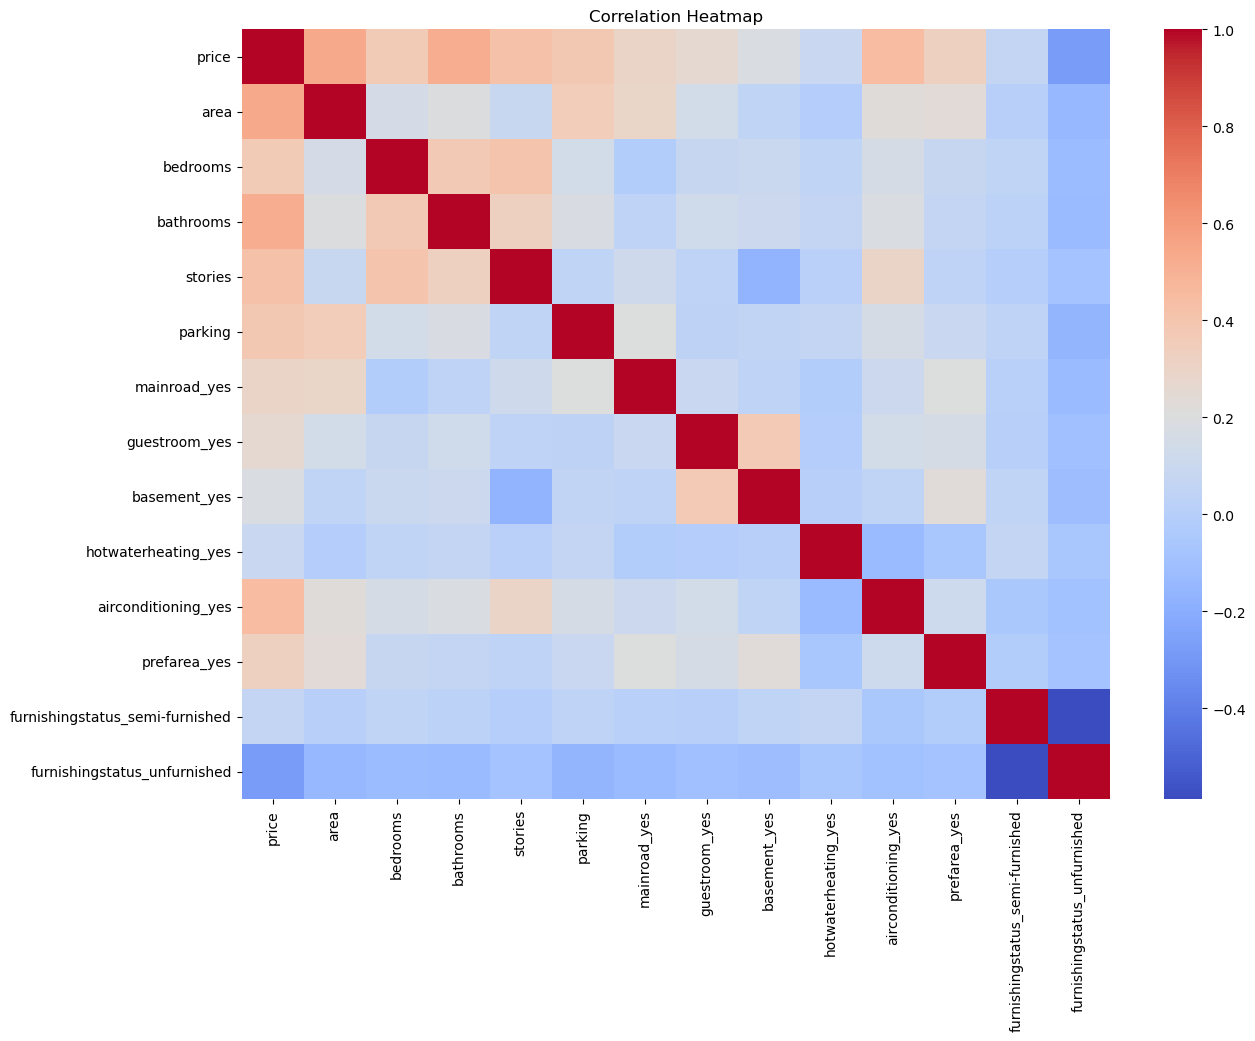

In [24]:
plt.figure(figsize=(14,10))

corr = df_encoded.corr()

sns.heatmap(corr,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

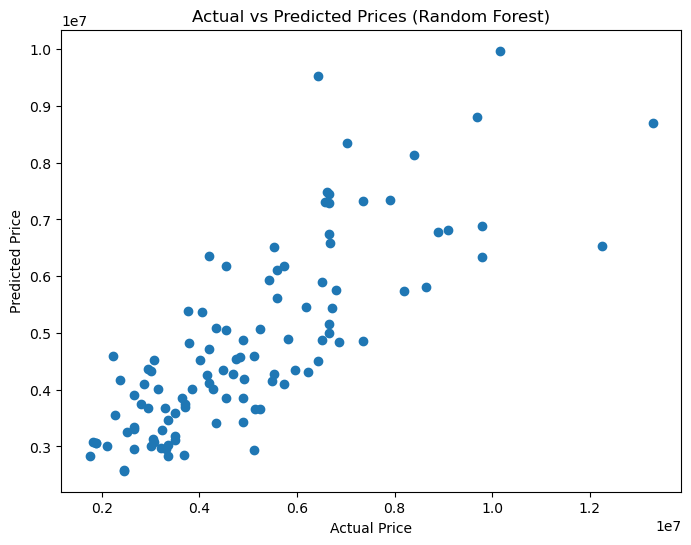

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")

plt.show()

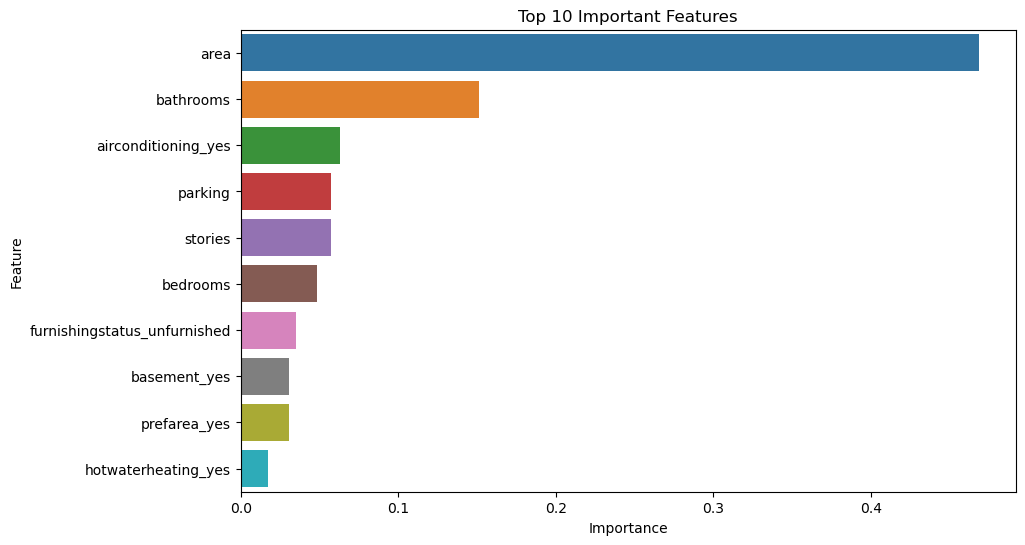

In [26]:
importance = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})

importance = importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x='Importance',y='Feature',data=importance.head(10))

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
#The analysis showed that area, number of bathrooms, number of stories, and parking availability were among the most influential factors affecting house prices. The correlation heatmap indicated that larger houses generally have higher prices. Among the two models tested, the Random Forest Regressor performed better than Linear Regression, achieving a higher R² score and lower prediction errors. This suggests that house prices are influenced by complex non-linear relationships that Random Forest can capture more effectively. One interesting observation was that some amenities such as air conditioning and preferred location significantly increased property value. Based on these findings, real estate businesses should focus on highlighting property size, amenities, and location features when pricing and marketing houses.